In [43]:
!pip install -q transformers
!pip install -q sentencepiece protobuf
!pip install -q tiktoken
!pip install -q transformers
!pip install -q spacy

!pip install -q emot

!pip install -q contractions

!pip install -q beautifulsoup4
!pip install -q wordsegment
!pip install -q vaderSentiment
!pip install -q NRCLex

In [ ]:
import numpy as np
import pandas as pd
import wordsegment as ws

import nltk
import zipfile
import os
import torch
import csv
import spacy
import re
import copy
import json
import contractions
import spacy
import random

from collections import Counter
from tqdm import tqdm

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer, PorterStemmer  

from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

from sklearn.metrics import confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, ParameterGrid

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModel, AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, get_scheduler, logging
from emot import UNICODE_EMOJI, EMOTICONS_EMO

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex

ws.load()

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
sia = SentimentIntensityAnalyzer()

model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

nlp = spacy.load("en_core_web_sm")

nltk.data.path.append('/kaggle/working/nltk_data')
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data')
nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data')
nltk.download('punkt', download_dir='/kaggle/working/nltk_data')
nltk.download('averaged_perceptron_tagger', download_dir='/kaggle/working/nltk_data')
nltk.download('vader_lexicon', download_dir="/root/nltk_data/")

nltk_path = '/kaggle/working/nltk_data/corpora/'
 
with zipfile.ZipFile(nltk_path + 'wordnet.zip', 'r') as zip_ref:
    zip_ref.extractall(nltk_path)
 
with zipfile.ZipFile(nltk_path + 'omw-1.4.zip', 'r') as zip_ref:
    zip_ref.extractall(nltk_path)
 
nltk.data.path = ['/kaggle/working/nltk_data']
nltk.data.path.append("/root/nltk_data/") 

logging.set_verbosity_error()  # Disabilita i log di avviso

In [ ]:
def save_model(best_model, path):
    os.makedirs(path, exist_ok=True) 
    torch.save(best_model.state_dict(), f"{path}/pytorch_model.bin")
    print(f"Modello salvato correttamente in: {path}/pytorch_model.bin")

def save_test(test_dataloader, model, device, i):
    predict = []
    output_csv_path = f"test_tweet_label{i}.csv"
    model.eval()  

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            extra_features = batch["extra_features"].to(device)  

            logits = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
            predictions = torch.argmax(logits, dim=-1)

            predict.extend(predictions.cpu().numpy())
    
    # Salva le predizioni in un file CSV
    with open(output_csv_path, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        for y in predict:
            writer.writerow([y]) 
    return predict

def conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predetto")
    plt.ylabel("Vero")
    plt.title("Matrice di Confusione")
    plt.show()

def plot_learning_curves(history, title="Learning Curves"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.ylim(0, max(max(history['train_loss']), max(history['val_loss'])) * 1.1)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.ylim(0, max(max(history['train_accuracy']), max(history['val_accuracy'])) * 1.1)
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['f1_macro'], label='F1-macro')
    plt.plot(epochs, history['f1_weighted'], label='F1-weighted')
    plt.xlabel('Epochs')
    plt.ylabel('F1')
    plt.title('F1 Curve')
    plt.ylim(0, max(max(history['f1_macro']), max(history['f1_weighted'])) * 1.1)
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def import_data(preprocessing):
    train_x_path = "./datasets/irony/train_text.txt"
    train_y_path = "./datasets/irony/train_labels.txt"
    val_x_path = "./datasets/irony/val_text.txt"
    val_y_path = "./datasets/irony/val_labels.txt"
    test_x_path = "./datasets/irony/test_text.txt"

    with open(train_x_path, "r", encoding="utf-8") as f:
        train_x = [line.strip() for line in f]

    with open(train_y_path, "r", encoding="utf-8") as f:
        train_y = [int(line.strip()) for line in f]

    with open(val_x_path, "r", encoding="utf-8") as f:
        val_x = [line.strip() for line in f]

    with open(val_y_path, "r", encoding="utf-8") as f:
        val_y = [int(line.strip()) for line in f]

    with open(test_x_path, "r", encoding="utf-8") as f:
        test_x = [line.strip() for line in f]

    
    train_numerical_features = np.array([extract_features_scaler(tweet) for tweet in train_x])
    scaler = StandardScaler()
    scaler.fit(train_numerical_features)

    train_dataset = IronyDataset(train_x, train_y, tokenizer, max_length=128, preprocessing = preprocessing, scaler = scaler)

    extra_scaler = extract_features_scaler(train_x[0]) 
    extra_f = extract_features(train_x[0])  
    extra_norm = extract_features_normalizated(train_x[0])
    
    num_extra = len(extra_scaler) + len(extra_f) + len(extra_norm)

    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

    val_dataset = IronyDataset(val_x, val_y, tokenizer, max_length=128, preprocessing = preprocessing, scaler = scaler)
    val_dataloader = DataLoader(val_dataset, batch_size=16)

    test_dataset = IronyDataset(test_x, None, tokenizer, max_length=128, preprocessing = preprocessing, scaler = scaler)
    test_dataloader = DataLoader(test_dataset, batch_size=16)

    return train_dataloader, val_dataloader, test_dataloader, val_y, num_extra

In [46]:
chat_words = {
    "?4U": "I have a question for you",
    "^^": "Read line above",
    "121": "one-to-one",
    "<3": "love",
    "2": "to",
    "2mrw": "tomorrow",
    "4": "for",
    "afk": "away from keyboard",
    "aka": "also known as",
    "asaè": "as soon as possible",
    "a/s/l": "age/sex/location",
    "ayt": "Are you there?",
    "b2w": "back to work",
    "b4": "before",
    "bbl": "Be back later",
    "bbs": "Be back soon",
    "bf": "boyfriend",
    "bff": "best friend forever",
    "brb": "Be right back",
    "btw": "by the way",
    "cmb": "Call me back",
    "cmiiw": "Correct me if I'm wrong",
    "cu": "See you",
    "cu l8r": "See you later",
    "cuz": "because",
    "cos": "because",
    "cmyl": "Chat with you later",
    "dc": "disconnected",
    "diy": "Do it yourself",
    "dm": "Direct Message",
    "f2f": "face-to-face",
    "faq": "frequently asked questions",
    "fb": "Facebook",
    "fyi": "for your information",
    "fyeo": "for your eyes only",
    "gb": "goodbye",
    "gf": "girlfriend",
    "gg": "Gotta go",
    "gl": "good luck",
    "gr8": "great!",
    "hbd": "Happy Birthday",
    "hhhhhh": "very funny",
    "how r u": "How are you?",
    "ic": "I see",
    #"idk": "I don't know",
    "imho": "in my humble opinion",
    "ik": "I know",
    "im": "Instant Message",
    "iow": "in other words",
    "j/k": "just kidding",
    "k": "OK",
    "l8r": "goodbye",
    #"lol": "laugh out loud",
    "m/f": "male or female?",
    "mins": "minutes",
    "msg": "message",
    "nv": "nevermind",
    "oic": "Oh, I see",
    "otw": "on the way",
    "p2p": "person-to-person",
    "plz": "please",
    "pm": "Private Message",
    "rofl": "rolling on the floor laughing",
    "ruok": "Are you okay?",
    "syl": "See you later",
    "tgif": "Thank goodness it's Friday",
    "thx or thnx": "thanks",
    "ttfn": "ta ta for now",
    "ttyl": "Talk to you later",
    "tyt": "Take your time",
    "u": "you",
    "u2": "you too",
    "ur": "your",
    "w/": "with",
    "w/o": "without",
    "wru": "Where are you?",
    "xo": "love",
    "zzz": "tired",
    "1/2": "half"
}

def lemmatize_text_spacy_preserve_case(text):
    """Applica la lemmatizzazione mantenendo la maiuscola originale."""
    doc = nlp(text)
    lemmatized_tokens = []

    for token in doc:
        lemma = token.lemma_  # Lemmatizzazione
        if token.text.isupper():  # Manteniamo le parole originali in maiuscolo
            lemma = lemma.upper()
        elif token.text.istitle():  # Manteniamo il titolo se necessario
            lemma = lemma.capitalize()
        lemmatized_tokens.append(lemma)

    return " ".join(lemmatized_tokens)

def replace_emoji_with_description(text):
    for emoji, description in UNICODE_EMOJI.items():
        description = description.replace('_', ' ')
        description = description.replace(':', ' ')
        text = text.replace(emoji, description)

    for emoticon, description in EMOTICONS_EMO.items():
        description = description.replace('_', ' ')
        description = description.replace(':', ' ')
        text = text.replace(emoticon, f" {description} ")
    return text

def hashtag_divide(sentence):
    hashtag = " ".join(ws.segment(sentence)) 
    return hashtag

def detect_polarity_flip_score(text, use_sigmoid=False):
    # Spezza il testo in frasi usando regex per separare su , . ! ?
    sentences = re.split(r'[,.!?]', text)
    sentences = [s.strip() for s in sentences if s.strip()]  

    if len(sentences) < 2:
        return 0.0 

    sentiments = []
    
    for sentence in sentences:
        score = sia.polarity_scores(sentence)['compound']
        sentiments.append(score)

    polarity_flip_count = 0
    for i in range(len(sentiments) - 1):
        if sentiments[i] * sentiments[i + 1] < 0: 
            polarity_flip_count += 1

    polarity_flip_score = polarity_flip_count / (len(sentences) - 1)

    # Normalizzo con sigmoide
    if use_sigmoid:
        polarity_flip_score = 1 / (1 + np.exp(-polarity_flip_count))

    return round(polarity_flip_score, 3)

def count_upper(text):
    count = 0
    count_upper = 0
    for s in text:
        if s.isalpha():
            if s.isupper():
                count_upper +=1
            count += 1
    return count_upper / count if count > 0 else 0.0

def count_esclamation(text):
    count = 0
    for s in text:
        if s == '!' or s == '?':
            count += 1
    return count

def count_extra_char(text):
    repeated_sequences = re.findall(r"(\w)\1{2,}", text)  
    num_repeated_letters = len(repeated_sequences)
    return num_repeated_letters

def clean_repeated_letters(word):
    return re.sub(r'(.)\1{2,}', r'\1', word)

def extract_interjections_spacy(text, max_length=3):

    cleaned_text = " ".join([clean_repeated_letters(word) for word in text.split()])

    doc = nlp(cleaned_text)

    interjections = []
    for token in doc:
        if token.pos_ == "INTJ":
            if len(token.text) <= max_length:
                interjections.append(token.text.capitalize())

    return len(interjections)
    
def count_emoticons(text):
    emoticon_count = 0

    for emoticon in EMOTICONS_EMO.keys():
        if re.match(r'^[a-zA-Z0-9]+$', emoticon):
            pattern = rf'\b{re.escape(emoticon)}\b' 
        else:
            pattern = rf'(?<!\S){re.escape(emoticon)}(?!\S)' 

        emoticon_count += len(re.findall(pattern, text, re.IGNORECASE))

    return emoticon_count

def remove_slash_n(texts):
    modified_texts = []  
    for sentence in texts:
        cleaned_sentence = re.sub(r"(\\n|\n)+", " ", sentence)  
        modified_texts.append(cleaned_sentence)  

    return modified_texts

def remove_tag(texts):
    modified_texts = []
    for sentence in texts:
        cleaned_sentence = re.sub(r"@\w+", "", sentence)  
        modified_texts.append(cleaned_sentence)

    return modified_texts

def remove_link(texts):
    modified_texts = [] 
    for sentence in texts:
        cleaned_sentence = re.sub(r'http\S+|www.\S+', '', sentence) 
        modified_texts.append(cleaned_sentence)

    return modified_texts

def replace_chat_words(sentence, chat_words_dict):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in chat_words_dict.keys()) + r')\b', re.IGNORECASE)
    
    def replace(match):
        word = match.group(0).lower()  
        return chat_words_dict.get(word, word)  
    
    return pattern.sub(replace, sentence)

Modello con rete aggiuntiva in modo da elaborare anche le nuove features

In [ ]:
class DeBERTaWithFeatures(nn.Module):
    def __init__(self, model_name, hidden_dim, num_extra_features, num_classes, dropout = 0.3):
        super(DeBERTaWithFeatures, self).__init__()
        config = AutoConfig.from_pretrained(model_name)
        config.hidden_dropout_prob = dropout
        self.deberta = AutoModel.from_pretrained(model_name, config=config)

        input_size = hidden_dim + num_extra_features

        self.classifier = nn.Sequential(
            nn.Linear(input_size, 256),  
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),  
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)  
        )

    def forward(self, input_ids, attention_mask, extra_features, labels=None):
        outputs = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # Estrai il token [CLS]

        if extra_features.dim() == 1:
            extra_features = extra_features.unsqueeze(0)

        if cls_embedding.shape[0] != extra_features.shape[0]:
            raise ValueError(f"Mismatch batch size: cls_embedding {cls_embedding.shape}, extra_features {extra_features.shape}")

        x = torch.cat([cls_embedding, extra_features], dim=1)

        logits = self.classifier(x)

        if labels is not None:  
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
            return logits, loss

        return logits

Funzioni per estrarre le Features

In [48]:
def extract_features_scaler(tweet):
    """ Estrae solo le feature numeriche da scalare """
    features = []

    ################ Features binaria, se è presenta almeno un Emoji o HashTag ironico ##################
    if features_active["emoji_hashtag_ironiche"]:
        irony_emojis = ["😒", "😑", "😷", "😤", "🙀", "👯", "🍻", "😫", "😳", "😱", "🔫"]
        target_hashtags = ['#ha', '#fml', '#rape', '#uber', '#shocker', '#sonyhack', '#thanksobama', '#gamergate', 
                           '#fb', '#mtvstars', '#happymonday', '#trolls', '#blessed', '#sorrynotsorry', '#cfbplayoff', 
                           '#annoying', '#bbn', '#handsupdontshoot', '#fashion', '#zzzz', '#kashmir', '#cuba', '#lfc', 
                           '#insomnia', '#awesome', '#naah', '#cameronmustgo', '#lifegoals', '#sonakshi', '#security', 
                           '#pissed', '#notfun', '#hypocrites', '#finalsweek', '#billcosby', '#gharwapsi']
    
        has_ironic_emoji = any(e in tweet for e in irony_emojis)
        has_ironic_hashtag = any(h in tweet.lower() for h in target_hashtags)
    
        features.append(1 if has_ironic_emoji or has_ironic_hashtag else 0)


    ########### Conto i ? e ! in un tweet #############
    if features_active["interrogativi_esclamativi"]:
        esclamation_features = count_esclamation(tweet)
        features.append(esclamation_features)

    ########## Conto se ci sono caratteri ripetuti più di tre volte ###########
    if features_active["caratteri_ripetuti"]:
        extra_char_features = count_extra_char(tweet)
        features.append(extra_char_features)

    ########## Conto Esclamazioni "Wow" o "Oh" #############
    if features_active["escalamazioni"]:
        extra_interjections_features = extract_interjections_spacy(tweet)
        features.append(extra_interjections_features)

    ############## Conto se ci sono path esclamativi (Fantastico!!!!!!) ###############
    if features_active["count_path_esclamativi"]:
        exclamation_count = len(re.findall(r"!{2,}", tweet))
        features.append(exclamation_count)

    ############ Conto la presenza di Virgolette ############
    if features_active["count_virgolette"]:
        quote_count = tweet.count('"')
        features.append(quote_count)

    ########## Conto il numero di Emoji Stilizzate #############
    if features_active["count_emoji_stilizzate"]:
        emoji_features = count_emoticons(tweet)
        features.append(emoji_features)

    ########## Conto il numero di Menzioni @user #############
    if features_active["count_tag"]:
        mentions_count = len(re.findall(r"@\w+", tweet))
        features.append(mentions_count)
    
    return np.array(features, dtype=np.float32) 

def extract_features(tweet):
    ########### Calcolo la percentuali di emozioni all'interno del tweet ############
    emotion_analysis = NRCLex(tweet)
    emotions = ["fear", "anger", "anticipation", "trust", "surprise", "positive", "negative", "sadness", "disgust", "joy"]
    emotion_scores = np.array([emotion_analysis.affect_frequencies.get(emotion, 0) for emotion in emotions], dtype=np.float32)
    return np.array(emotion_scores, dtype=np.float32)
    
def extract_features_normalizated(tweet):    
    features = []

    ############# POS Tengo il conto di nomi, verbi, aggettivi e avverbi #############
    if features_active["pos"]:
        words = nltk.word_tokenize(tweet) 
        pos_tags = [tag for _, tag in nltk.pos_tag(words)]
        pos_counts = Counter(pos_tags)

        pos_array = np.array([pos_counts.get(tag, 0) for tag in ['NN', 'VB', 'JJ', 'RB']], dtype=np.float32)
        total_words = len(words)
        if total_words > 0:  
            pos_array = pos_array / total_words
    
        features.extend(pos_array)

    ############# Conto il numero di Maiuscole / Numero di lettere nel tweet ##############
    if features_active["count_maiuscole"]:
        upper_feature = count_upper(tweet)
        features.append(upper_feature)

    ############# Polarity Flip ###############
    if features_active["polarity"]:
        polarity_feature = detect_polarity_flip_score(tweet)
        features.append(polarity_feature)

    return np.array(features, dtype=np.float32)

Classe per elaborare il testo

In [50]:
class IronyDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length, preprocessing, scaler):

        cleaned_texts = texts.copy()
        self.extra_features = []
        self.scaler = scaler
        
        #Rimuvo i link
        if preprocessing["remove_link"]:
            cleaned_texts = remove_link(cleaned_texts)
        
        #Sostituisco le chatwords <3 -> love, 2mr -> tomorrow
        if preprocessing["chatwords"]:
            cleaned_texts = [replace_chat_words(sentence, chat_words) for sentence in cleaned_texts]
            
        # Espando le contrazionie i'm -> i am    
        if preprocessing['expand_contractions']:
            cleaned_texts = [contractions.fix(sentence) for sentence in tqdm(cleaned_texts, desc="expand contractions preprocessing")]

        #Estraggo le features
        if preprocessing["extra_features"]:

            # Estraggo features gia' normalizzate
            features_norm = np.array([extract_features_normalizated(tweet) for tweet in cleaned_texts])

            # Estraggo features da riscalare con StandardScaler()
            features_scaled = np.array([extract_features_scaler(tweet) for tweet in cleaned_texts])
            all_features_scaled = self.scaler.transform(features_scaled)

            # Estrai feature da non riscalare
            emotional_features = np.array([extract_features(tweet) for tweet in cleaned_texts])

            # Concatenazione finale
            self.extra_features = np.hstack([all_features_scaled, emotional_features,features_norm])
            
        # Toglie # dagli hashtag 
        if preprocessing["hashtag"]:
            cleaned_texts = [' '.join([hashtag_divide(word) if word[0] == "#" else word for word in sentence.split()]) for sentence in cleaned_texts]
        
        #Rimuove \n
        if preprocessing['remove_slash_n']:
            cleaned_texts = remove_slash_n(cleaned_texts)

        #Modifica delle emoji
        if preprocessing['change_emoticon']:
            cleaned_texts = [replace_emoji_with_description(text) for text in tqdm(cleaned_texts, desc="change emoticon preprocessing")]

        # Rimuovi tag utenti (@user)
        if preprocessing['remove_tag']:
            cleaned_texts = remove_tag(cleaned_texts)
            
        if preprocessing['remove_number']:
            cleaned_texts = [re.sub(r"\s([0-9]+[:|.]*[0-9]*)\s", "", sentence) for sentence in cleaned_texts]
        
        # Lemmatizzazione, Es. i am -> i be
        if preprocessing['apply_lemmatization']:
            cleaned_texts = [' '.join([lemmatizer.lemmatize(word) for word in nltk.word_tokenize(text)]) for text in cleaned_texts]

        # Normalizzo il testo trasformandolo tutto in minuscolo
        if preprocessing['lower']:
            cleaned_texts = [sentence.lower() for sentence in cleaned_texts]
            
        self.texts = [re.sub(r"\s+", " ", sentence).strip() for sentence in cleaned_texts]
        
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.extra_features = np.array(self.extra_features)


    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        extra_features = torch.tensor(self.extra_features[idx], dtype=torch.float32)

        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "extra_features": extra_features,
                "labels": label
            }
        else:
            return {
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "extra_features": extra_features
            }

Classe EarlyStopping

In [52]:
class EarlyStopping:
    def __init__(self, patience = 3, min_delta = 0.0):

        self.best_model = None
        self.patience = patience
        self.min_delta = min_delta              
                                              
        self.counter = 0                       
        self.early_stop = False                
        self.max_accuracy = 0

    def __call__(self, val_accuracy, model):

        if (self.max_accuracy - val_accuracy) >= self.min_delta:
            self.counter += 1 
            print(f"Early stop: {self.counter}")                           
            if self.counter >= self.patience:
                self.early_stop = True
                print("Early stop!")
        else:                       
            #Utilizzimao come metrica l'accuracy sul validation                                     
            if val_accuracy >= self.max_accuracy: 
                self.max_accuracy = val_accuracy                     
                self.best_model = copy.deepcopy(model)                                            
            self.counter = 0

Funzione per il Fine Tuning

In [ ]:
def train(train_dataloader, val_dataloader, model, device, config, patience, min_delta):
    warmup_steps = config['warmup_steps']
    weight_decay = config['weight_decay']
    lr = config['lr']
    num_epochs = config['epochs']
    scheduler = config['scheduler']

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "f1_macro": [],
        "f1_weighted": []
    }
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,weight_decay=weight_decay)
    num_training_steps = len(train_dataloader) * num_epochs
    lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_training_steps)
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs} - Training"):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            logits, loss = model(batch["input_ids"], batch["attention_mask"], batch["extra_features"], labels=batch["labels"])
            
            train_loss += loss.item()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            probabilities = torch.softmax(logits, dim=-1)
            predictions = torch.argmax(probabilities, dim=-1)
            
            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

        train_loss /= len(train_dataloader)
        train_accuracy = correct / total
        
        val_loss, val_accuracy, f1_macro, f1_weighted = validation(val_dataloader, model, device)
        print(f"Epoch {epoch + 1}, Training Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")
            
        print(f"F1 Score (Macro): {f1_macro:.4f}, F1 Score (Weighted): {f1_weighted:.4f}")

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['f1_macro'].append(f1_macro)
        history['f1_weighted'].append(f1_weighted)
        early_stopping(f1_macro, model)
        if early_stopping.early_stop:
            print("Early stopping attivato!")
            break

    return early_stopping.best_model, history

Funzione per calcolare le metriche

In [54]:
def validation(val_dataloader, model, device, label=False):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    val_pred = []
    val_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            logits, loss = model(batch["input_ids"], batch["attention_mask"], batch["extra_features"], labels=batch["labels"])

            val_loss += loss.item()
            predictions = torch.argmax(logits, dim=-1)

            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

            val_pred.extend(predictions.cpu().numpy())
            val_labels.extend(batch["labels"].cpu().numpy())

    val_loss /= len(val_dataloader)
    accuracy = correct / total

    f1_macro = f1_score(val_labels, val_pred, average='macro')
    f1_weighted = f1_score(val_labels, val_pred, average='weighted')
    
    if label:
        return val_pred, f1_macro,f1_weighted
    
    return val_loss, accuracy, f1_macro,f1_weighted

1. 1
['extra_features', 'remove_link', 'apply_lemmatization']
Testing combination: {'batch_size': 16, 'dropout_rate': 0, 'epochs': 50, 'lr': 8e-06, 'min_delta': 0.0, 'patience': 5, 'scheduler': 'linear', 'warmup_steps': 0.1, 'weight_decay': 0.01}
📊 Estrazione e normalizzazione delle feature extra...
📊 Estrazione e normalizzazione delle feature extra...
📊 Estrazione e normalizzazione delle feature extra...


Epoch 1/50 - Training: 100%|██████████| 179/179 [00:47<00:00,  3.75it/s]


Epoch 1, Training Loss: 0.6733, Train Accuracy: 0.5877, Validation Loss: 0.6299, Accuracy: 0.6063
F1 Score (Macro): 0.5804, F1 Score (Weighted): 0.5758


Epoch 2/50 - Training: 100%|██████████| 179/179 [00:47<00:00,  3.75it/s]


Epoch 2, Training Loss: 0.5460, Train Accuracy: 0.7386, Validation Loss: 0.5424, Accuracy: 0.7236
F1 Score (Macro): 0.7233, F1 Score (Weighted): 0.7229


...

Epoch 27, Training Loss: 0.0219, Train Accuracy: 1.0000, Validation Loss: 0.8927, Accuracy: 0.7634
F1 Score (Macro): 0.7631, F1 Score (Weighted): 0.7635
EarlyStop: 3


Epoch 28/50 - Training: 100%|██████████| 179/179 [00:47<00:00,  3.76it/s]


Epoch 28, Training Loss: 0.0185, Train Accuracy: 1.0000, Validation Loss: 0.8905, Accuracy: 0.7634
F1 Score (Macro): 0.7631, F1 Score (Weighted): 0.7635
EarlyStop: 4


Epoch 29/50 - Training: 100%|██████████| 179/179 [00:47<00:00,  3.76it/s]


Epoch 29, Training Loss: 0.0288, Train Accuracy: 0.9962, Validation Loss: 0.8130, Accuracy: 0.7623
F1 Score (Macro): 0.7620, F1 Score (Weighted): 0.7624
EarlyStop: 5
Early stop!
Early stopping attivato!


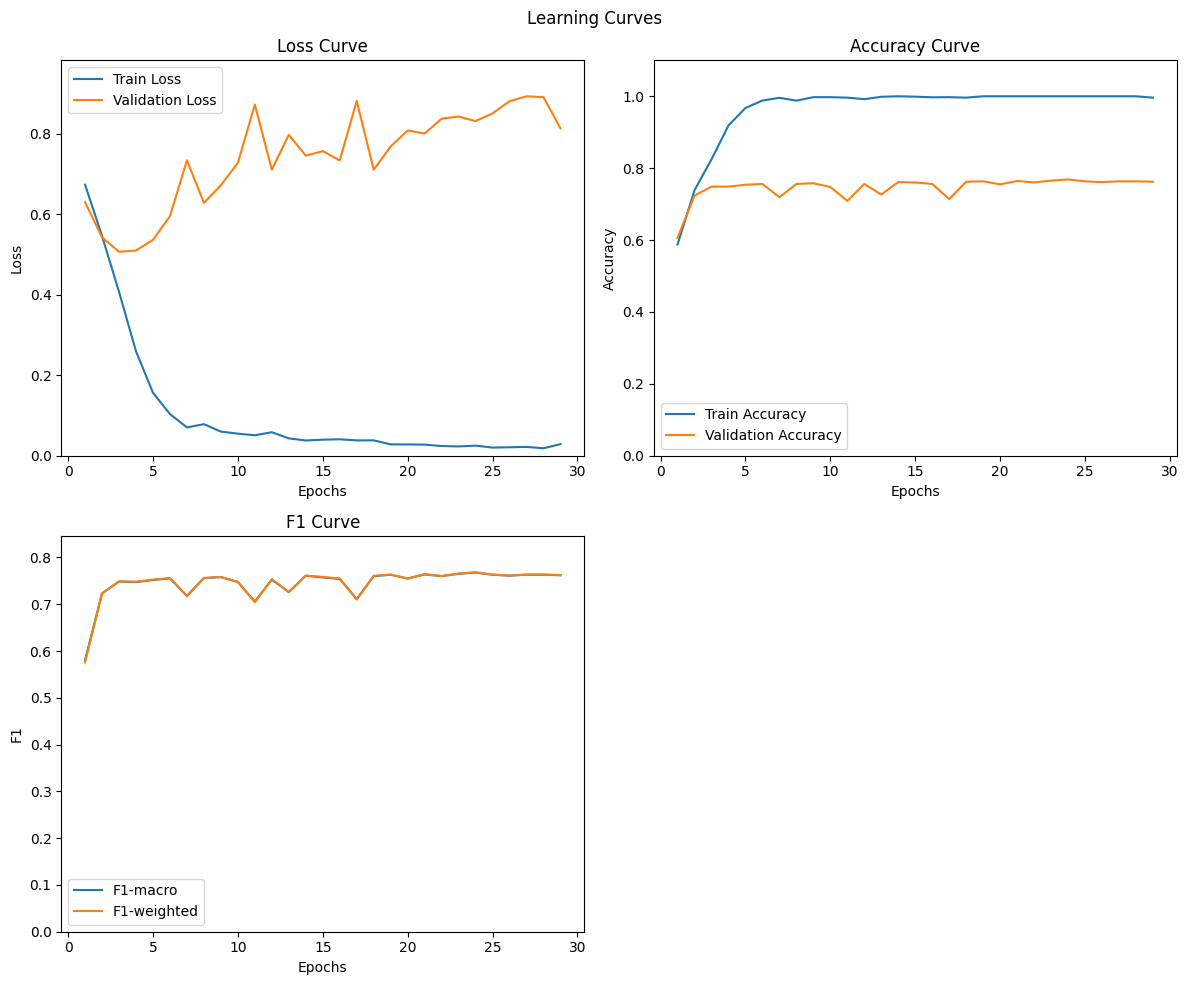

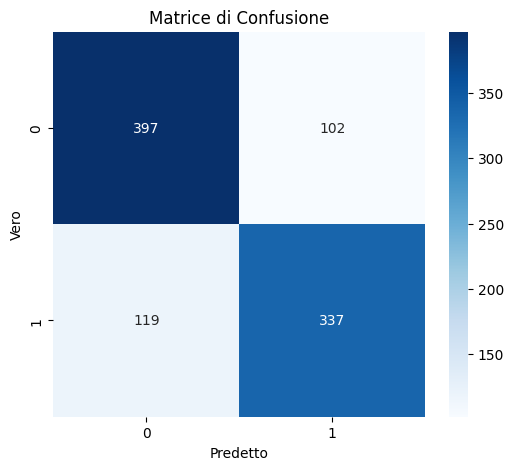

Modello salvato correttamente in: ./irony_model_batch_size_16_dropout_rate_0_epochs_50_lr_8e-06_min_delta_0.0_patience_5_scheduler_linear_warmup_steps_0.1_weight_decay_0.01_f1Macro_0.7677_f1Weighted_0.7683/pytorch_model.bin
0.7676693177752703 0.7683265510310908


In [ ]:
#Best Iperparameter
param_grid = {
    'lr': [8e-6],
    'epochs': [50],
    'batch_size':[16],
    'weight_decay': [0.01],
    'dropout_rate': [0],
    'warmup_steps': [0.1],
    'scheduler': ["linear"],
    'patience' : [5],
    'min_delta' : [0.0]
}

grid = ParameterGrid(param_grid)

features_active = {
    "emoji_hashtag_ironiche": False, # verfica se sono presenti emoji e hahtag ironici
    "interrogativi_esclamativi": False, # !/?
    "caratteri_ripetuti": True, # count di quante volte trovo lettere ripetute
    "escalamazioni": False, # Woo, Oh
    "count_emoji_stilizzate": False, # O.o, >-<, U_U
    "count_tag": False, # @user
    "count_path_esclamativi": False, # Fantastico!!!!! (più di uno !)
    "count_virgolette": True, # " ... "

    "sentiment" : True, # Percentuale di emozione rilevatap (Non si può spegnere)
    
    "pos" : True, # nome, verbi, avverbi, aggettivi
    "count_maiuscole" : False, #conta maiuscole / totale lettere
    "polarity" : False, # frase positiva, frase negativa (ossimoro)
}

preprocessing = {
    "extra_features": True,
    "hashtag" : False,
    "chatwords": False,
    "remove_slash_n": False,
    "remove_link": True,
    "change_emoticon":False,
    "remove_tag":False,
    "expand_contractions":False,
    "apply_lemmatization":True,
    "remove_number":False,
    "lower":False
}

true_keys = [key for key, value in preprocessing.items() if value]

i=0
for iperparameters_config in grid:
    i = i + 1
    
    print("1.", i)
    print(true_keys)
    print(f"Testing combination: {iperparameters_config}")

    train_dataloader, val_dataloader, test_dataloader, val_y, num_extra_features  = import_data(preprocessing)
    torch.cuda.empty_cache()
    
    model = DeBERTaWithFeatures("microsoft/deberta-v3-base", hidden_dim=768, num_extra_features=num_extra_features, num_classes=2, dropout = iperparameters_config['dropout_rate'])#, pca_dim = pca_dim )
   
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_model, history = train(train_dataloader, val_dataloader, model, device, iperparameters_config,iperparameters_config['patience'],iperparameters_config['min_delta'])
    plot_learning_curves(history)
    
    val_pred, f1_macro,f1_weighted = validation(val_dataloader, best_model, device, label=True)
    conf_matrix(val_y, val_pred)

    save_test(test_dataloader, best_model, device, i)

    name = "_".join([f"{key}_{str(value)}" for key, value in iperparameters_config.items()]) + f"_f1Macro_{f1_macro:.4f}_f1Weighted_{f1_weighted:.4f}"
    path = f"./irony_model_{name}"
    save_model(best_model, path)

    print(f1_macro,f1_weighted)
    
    with open(f"{path}/preprocessing_selected.json", 'w') as f:
        json.dump(preprocessing, f, indent=4)
    
    del model
    torch.cuda.empty_cache()